## 01. Bagging(Bootstrap Aggregating)
원본 데이터를 중복 허용 방식으로 여러 번 뽑아 여러 모델을 학습시키고, 예측 결과를 합치는 앙상블 방법 중 하나.

- Bootstrap - 원본 데이터에서 중복을 허용해 여러 번 샘플을 뽑는 것
- Aggregating - 여러 결과를 모아서 합치는 것



### 01-01. 왜 배우는가?

**단일 결정트리의 불안정성을 줄일 수 있음**
- 결정트리는 데이터가 조금만 달라져도 다른 트리가 만들어질 수 있음.
- 여러 트리를 만들고 결과를 합치면 한 트리의 실수가 전체 예측을 크게 흔들 가능성이 줄어듦.

**Random Forest의 원리를 이해할 수 있음**
- Random Forest는 Bagging 기반의 대표 모델임.
- 여러 결정트리를 만들고, 각 트리가 서로 다른 데이터와 feature 조합을 보게 함.

**모델 해석 지표를 함께 연습할 수 있음**
- Random Forest는 feature importance를 제공함.
- 단, 중요도는 인과관계가 아니라 모델이 분기에서 많이 사용한 상대적 기여도로 해석해야 함.

### 01-02. 핵심 용어

**Bootstrap sampling**
- 원본 데이터에서 중복을 허용해 샘플을 뽑는 방법임.
- 같은 샘플이 여러 번 뽑힐 수 있고, 어떤 샘플은 한 번도 뽑히지 않을 수 있음.

**Bagging**
- bootstrap sample 여러 개로 여러 모델을 학습시키는 방식임.
- 분류는 투표, 회귀는 평균으로 최종 예측을 만듦.

**Random Forest**
- 여러 결정트리를 사용하는 Bagging 기반 모델임.
- 트리마다 데이터 샘플을 다르게 뽑고, 노드 분할 시 일부 feature만 후보로 고려함.

**OOB (Out-Of-Bag)**
- bootstrap sampling에서 특정 트리 학습에 뽑히지 않은 데이터임.
- OOB 데이터를 검증 데이터처럼 사용해 성능을 추정할 수 있음.
    - 학습용 train 데이터, 평가용 test 데이터를 분리하는 것과 비슷
    - bootstrap sampling시 중복허용으로 인해 학습에 뽑히지 않은 train 데이터들을 test용 데이터로 사용하는 것.

### 01-03. Random Forest가 안정적인 이유

- 단일 결정트리는 한 데이터셋에 과하게 맞춰질 수 있음.
- Random Forest는 서로 다른 트리의 예측을 결합함.
- 각 트리가 서로 다른 데이터와 feature 조합을 보기 때문에 실수가 평균화될 수 있음.
- 그래서 과대적합이 심한 단일 트리보다 일반화 성능이 안정되는 경우가 많음.


## 02. 실습 환경 준비

- `BaggingClassifier`: 같은 기본 모델을 bootstrap sample마다 여러 번 학습시키는 분류 모델임.
- `RandomForestClassifier`: 여러 결정트리를 결합하는 대표 Bagging 기반 분류 모델임.
- `RandomForestRegressor`: 여러 결정트리의 숫자 예측값을 평균내는 회귀 모델임.
- 결정트리 계열은 feature의 순서와 분할 기준을 사용하므로 KNN/SVM처럼 스케일링이 필수는 아님.


In [1]:
# 데이터 처리와 시각화에 사용할 기본 라이브러리
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 예제 데이터셋
# load_breast_cancer: 유방암 진단 분류 데이터
# load_diabetes: 당뇨 진행 정도를 예측하는 회귀 데이터
from sklearn.datasets import load_breast_cancer, load_diabetes
from sklearn.externals.array_api_compat.dask.array import unique_counts

# train_test_split: 학습 데이터와 평가 데이터를 분리
# cross_validate: 교차검증으로 모델 성능을 여러 번 평가
# GridSearchCV: 여러 하이퍼파라미터 조합을 교차검증으로 비교
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV

# Bagging과 Random Forest의 기본 모델로 비교할 단일 결정트리
from sklearn.tree import DecisionTreeClassifier

# BaggingClassifier: 같은 종류의 모델을 여러 개 만들어 투표하는 앙상블
# RandomForestClassifier: 여러 결정트리를 만들되, 트리마다 일부 feature만 고려하는 분류 모델
# RandomForestRegressor: 여러 결정트리의 숫자 예측값을 평균내는 회귀 모델
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, RandomForestRegressor

# classification_report: precision, recall, f1-score를 한 번에 출력
# root_mean_squared_error: 회귀 예측 오차를 원래 target 단위로 확인
# r2_score: 회귀 모델이 target 변동을 얼마나 설명하는지 확인
from sklearn.metrics import classification_report, root_mean_squared_error, r2_score


## 03. Bootstrap sampling 직접 확인

- Bootstrap은 중복을 허용해 데이터를 뽑는 방식임.
- 전체 데이터 개수만큼 뽑아도 중복 때문에 빠지는 샘플이 생김.
- 빠진 샘플은 OOB 데이터로 볼 수 있음.


In [2]:
np.random.seed(42)
original_indices = np.arange(10)    # 0~9까지 존재하는 ndarray 생성

# 부트스트랩 샘플링: 중복 허용 랜덤 뽑기( == 복원 추출)
bootstrap_indices = np.random.choice(
    original_indices,
    size = len(original_indices),  # 10
    replace = True
)
print('원본: ', original_indices)
print('부트스트랩 샘플링:',  bootstrap_indices)

# setdiff1d == 차집합
oob_indices = np.setdiff1d(original_indices, bootstrap_indices)
print('OOB: ', oob_indices)
print("중복된 샘플 수: ", len(bootstrap_indices) - len(np.unique(bootstrap_indices)) )


원본:  [0 1 2 3 4 5 6 7 8 9]
부트스트랩 샘플링: [6 3 7 4 6 9 2 6 7 4]
OOB:  [0 1 5 8]
중복된 샘플 수:  4


## 04. Breast Cancer 데이터 로드

- `load_breast_cancer()`는 유방암 종양 특성으로 악성/양성을 분류하는 예제 데이터임.
- feature는 종양 반지름, 질감, 면적, 오목도 등 30개 수치 변수임.
- target은 `0=malignant`, `1=benign`임.


In [3]:
# as_frame=True를 사용하면 NumPy 배열이 아니라 pandas DataFrame/Series 형태로 반환됨.
# DataFrame으로 받으면 feature 이름을 유지할 수 있어 중요도 해석과 시각화가 쉬움.
cancer = load_breast_cancer(as_frame=True)

# rf_X: 모델이 입력으로 사용할 feature 데이터
# rf_y: 모델이 맞혀야 할 target 데이터
rf_X = cancer.data
rf_y = cancer.target

print('feature shape:', rf_X.shape)  # (샘플 수, feature 수)
print('target shape:', rf_y.shape)   # 샘플 수
print('target 이름:', cancer.target_names)

# DataFrame의 앞부분을 확인해 feature 이름과 값의 형태를 파악함.
display(rf_X.head())


feature shape: (569, 30)
target shape: (569,)
target 이름: ['malignant' 'benign']


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 05. 학습/평가 데이터 분리

- 분류 문제이므로 `stratify=rf_y`를 사용해 target 비율을 학습셋과 평가셋에 비슷하게 유지함.
- Random Forest는 트리 기반 모델이라 스케일링 없이 바로 학습할 수 있음.


In [4]:
rf_X_train, rf_X_test, rf_y_train, rf_y_test = train_test_split(
    rf_X,
    rf_y,
    test_size=0.2,
    random_state=42,
    stratify=rf_y
)

print('학습 데이터:', rf_X_train.shape, rf_y_train.shape)
print('평가 데이터:', rf_X_test.shape, rf_y_test.shape)

학습 데이터: (455, 30) (455,)
평가 데이터: (114, 30) (114,)


## 06. 단일 결정트리와 Bagging 비교

- 단일 결정트리는 데이터에 민감하여 트리구조가 크게 달라지거나 과대적합이 발생할 수 있음.
- BaggingClassifier는 여러 결정트리를 서로 다른 bootstrap sample로 학습시킴.
- 결과 표에서는 학습 점수, 평가 점수, OOB score를 함께 비교함.
- 둘 다 학습 점수가 높더라도 평가 점수가 더 안정적인지 보는 것이 중요함.

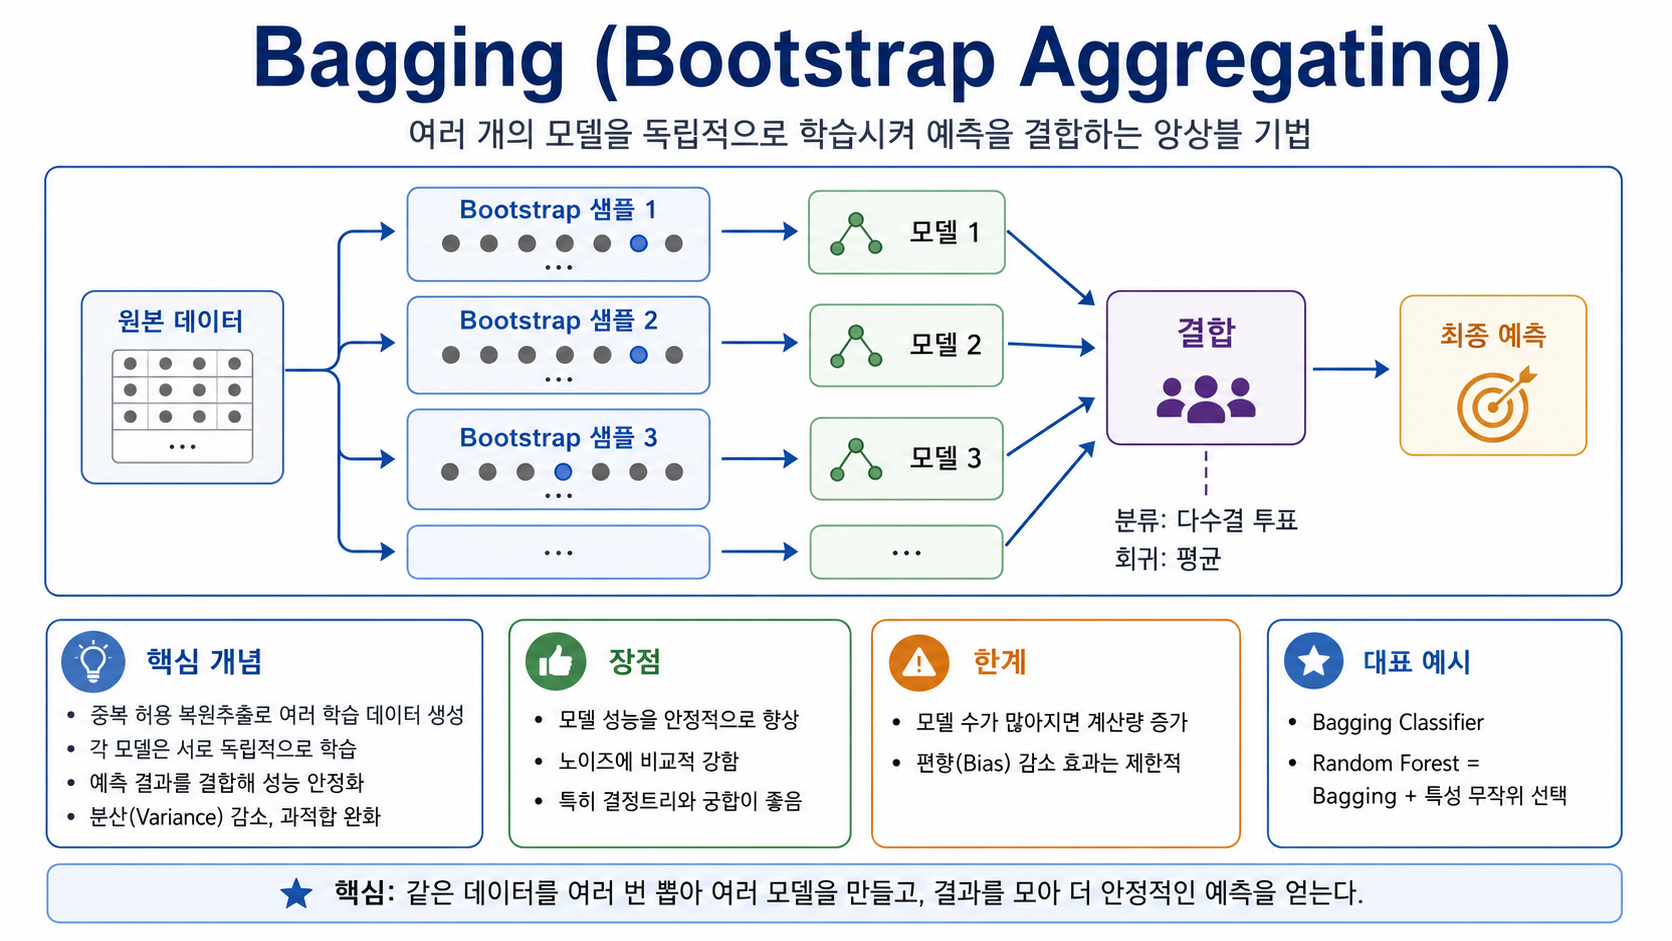

#### 간단한 예시 - 학생의 합격 여부를 예측

- 단일 결정트리:
  - 한 명의 선생님이 혼자 판단하는 것과 비슷함
  - 특정 기준에 너무 의존할 수 있음
  - 예: `공부시간이 5시간 이상이면 합격` 같은 규칙 하나가 크게 영향을 줌

- Bagging:
  - 여러 명의 선생님이 각자 판단한 뒤 다수결로 결정하는 것과 비슷함
  - 한 트리의 실수를 여러 트리가 보완할 수 있음
  - 단일 결정트리보다 예측이 더 안정적임

---

- BaggingClassifier() 파라미터
    - estimator: bootstrap sample마다 학습할 기본 모델 지정
    - n_estimators: 만들 기본 모델 개수
    - max_samples: 각 기본 모델이 학습에 사용할 샘플 비율.
    - bootstrap=True: 중복 허용 샘플링을 사용.
    - oob_score=True: OOB 데이터를 이용한 자체 검증 점수를 계산.

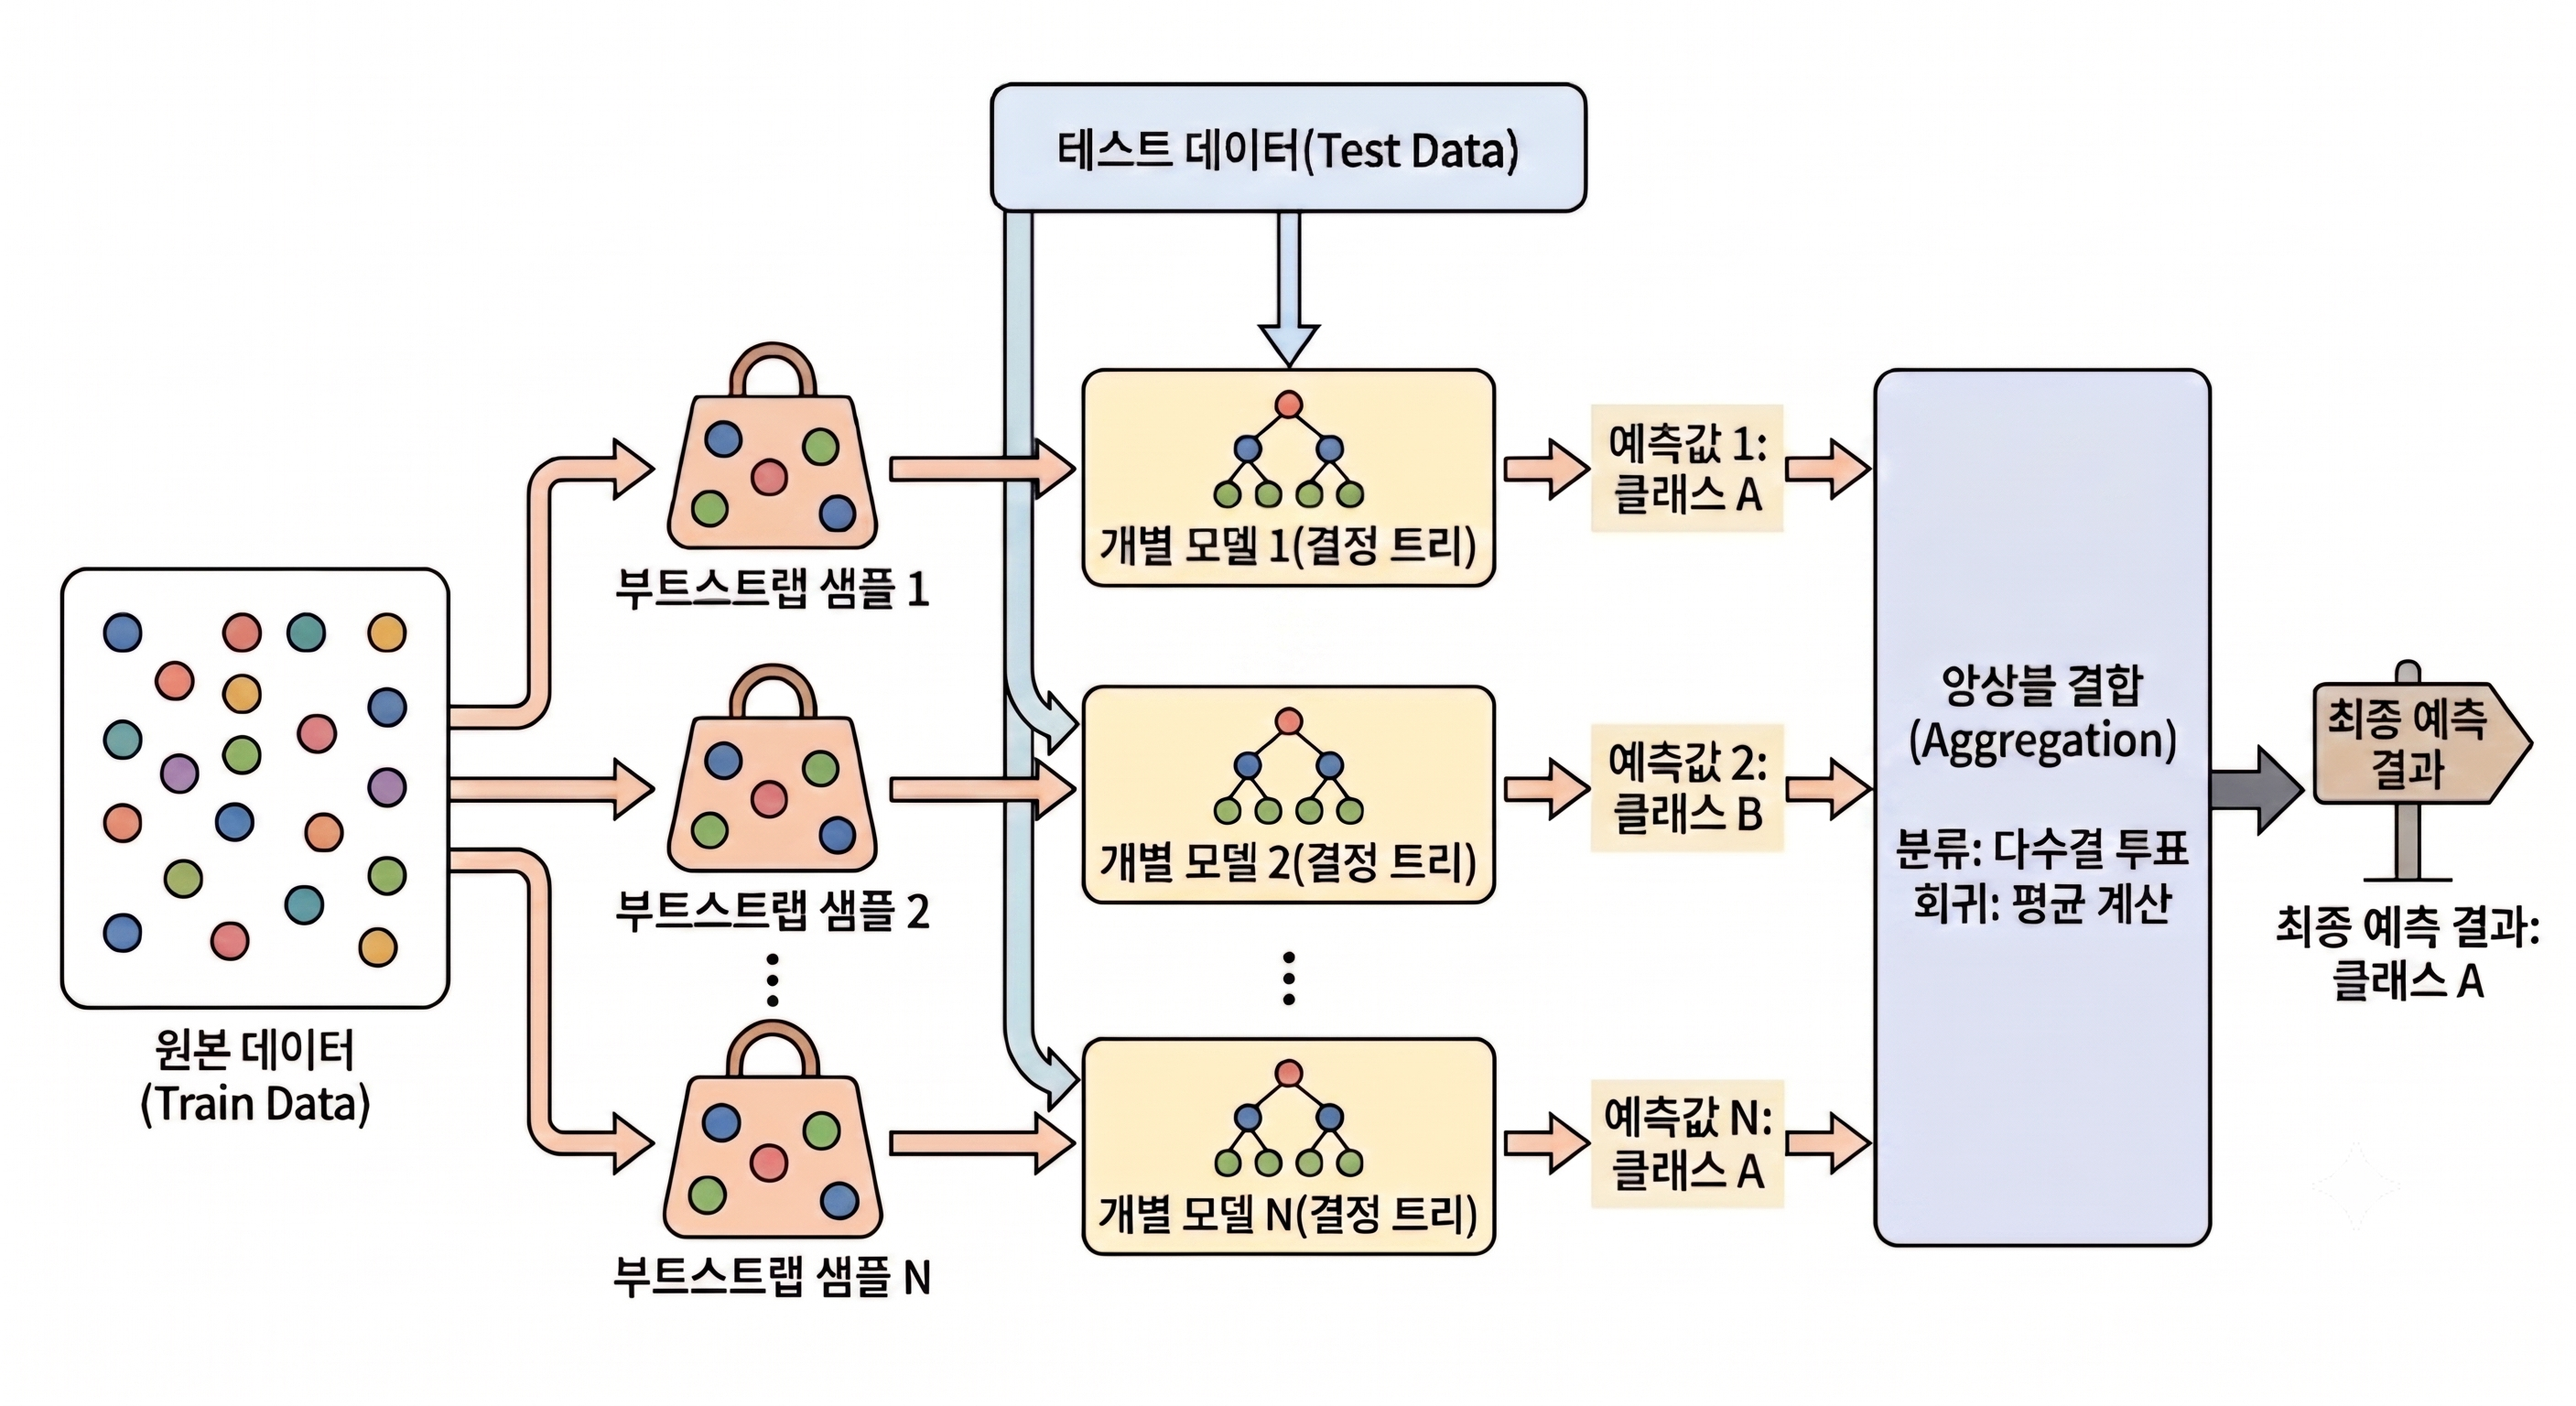

In [5]:
bagging_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=100,
    max_samples=0.8,    # 학습 데이터의 80% 크기만큼 부트스르랩 샘플링
    bootstrap=True,     # 복원 추출
    oob_score=True,      # 뽑히지 않은 샘플 데이터로 자체 성능 검증
    random_state=42,
    n_jobs=1    # 병렬 처리 개수
)

# 비교용 단일 결정 트리
single_tree_clf = DecisionTreeClassifier(random_state=42)

models_for_compare = {
    'single_tree': single_tree_clf,
    'bagging_tree': bagging_clf,
}

bagging_compare_results = []

for name, model in models_for_compare.items():
    model.fit(rf_X_train, rf_y_train)

    # score(): 분류 모델에서는 기본적으로 accuracy를 반환함.
    # train_accuracy와 test_accuracy 차이가 크면 과대적합 가능성을 의심할 수 있음.
    bagging_compare_results.append({
        'model': name,
        'train_accuracy': model.score(rf_X_train, rf_y_train),
        'test_accuracy': model.score(rf_X_test, rf_y_test),

        # 단일 결정트리에는 oob_score_ 속성이 없음.
        # getattr(..., np.nan)을 사용해 속성이 없을 때는 NaN으로 표시함.
        'oob_score': getattr(model, 'oob_score_', np.nan)
    })


bagging_compare_df = pd.DataFrame(bagging_compare_results)
display(bagging_compare_df)

,model,train_accuracy,test_accuracy,oob_score
0,single_tree,1.0,0.912281,NaN
1,bagging_tree,1.0,0.947368,0.956044


## 07. Random Forest

### 07-01.Random Forest란?
- Random Forest는 여러 개의 결정트리(Decision Tree)를 만들어서 예측 결과를 합치는 앙상블 모델.
- 한 개의 결정트리만 사용하면 데이터에 너무 민감해서 과대적합될 수 있음.
- Random Forest는 여러 트리를 만들고, 각 트리의 판단을 모아서 더 안정적인 예측을 만듦.

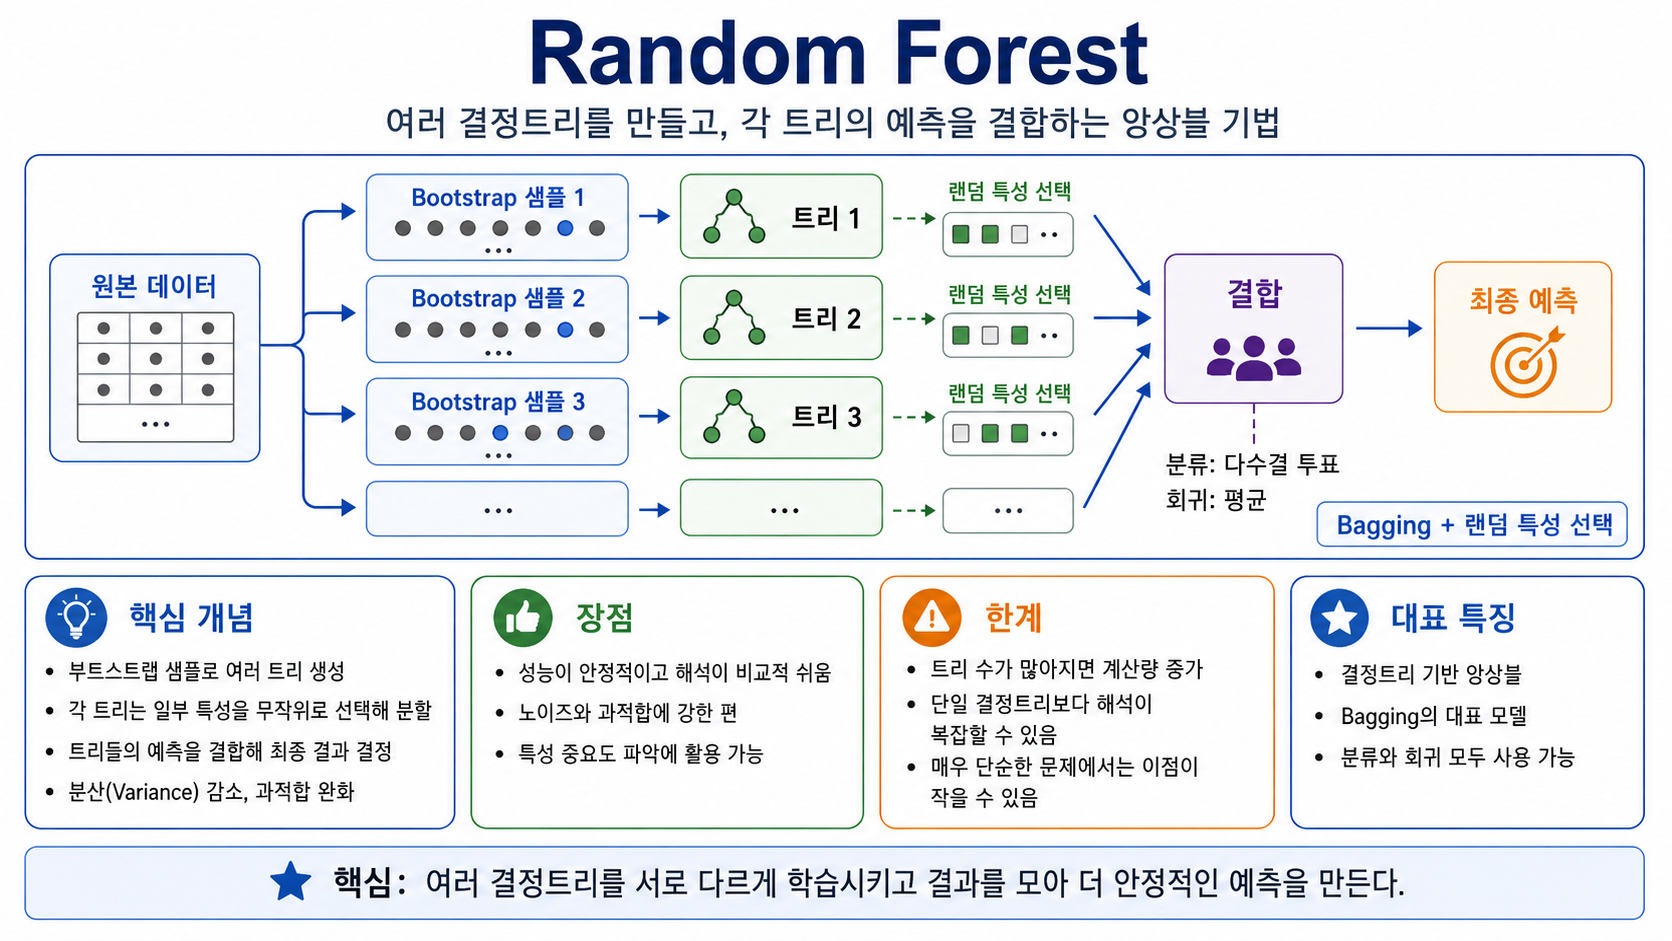

### 07-02. RandomForestClassifier
- Random Forest는 Bagging 기반으로 여러 결정트리를 학습함.
- 트리마다 bootstrap sample을 사용하고, 노드 분할 시 일부 feature만 후보로 고려함.

---
- RandomForestClassifier() 파라미터
    - n_estimators: 만들 결정 트리 모델 개수, 트리가 많을수록 예측이 안정될 수 있지만 학습 시간이 늘어남
    - max_depth: 각 트리의 최대 깊이
    - max_features='sqrt'
        - 각 노드에서 분할 기준을 찾을 때 전체 feature가 아니라 sqrt(전체 feature 수) 개만 무작위로 뽑아 후보로 사용
            - sqrt == 제곱근
            - ex) 전체 feature수가 25개이면 sqrt(25) == 5
        - Random Forest가 Bagging과 다른 핵심 지점이며, 트리들 사이의 다양성을 더 크게 만듦.
    - oob_score=True: 각 트리의 bootstrap sample에 포함되지 않은 데이터를 이용해 OOB 점수를 계산

In [8]:
rf_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    max_features='sqrt',    # sqrt == 제곱근(루트)
    random_state=42,    # 부트스트랩 샘플링 시 뽑히지 않은 데이터로 자체 평가
    oob_score=True,
    n_jobs=1
)

# 학습
rf_clf.fit(rf_X_train, rf_y_train)

# 예측
rf_y_pred = rf_clf.predict(rf_X_test)

# 정확도(평가)
print('학습셋 accuracy: ', rf_clf.score(rf_X_train, rf_y_train))
print('평가셋 accuracy: ', rf_clf.score(rf_X_test, rf_y_test))
print('OOB score: ', rf_clf.oob_score_)

print(classification_report(rf_y_test, rf_y_pred, target_names=cancer.target_names))

# 학습셋, 평가셋 점수가 모두 높고 차이가 적으면 과대적합 발생 X (안정적이라고 볼 수 있음)

학습셋 accuracy:  0.9934065934065934
평가셋 accuracy:  0.956140350877193
OOB score:  0.9582417582417583
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



## 08. Random Forest의 bootstrap sample 확인

- Random Forest의 각 트리는 서로 다른 bootstrap sample로 학습됨.
- `estimators_samples_`를 보면 각 트리가 어떤 학습 샘플 인덱스를 사용했는지 확인할 수 있음.
- 같은 인덱스가 반복되는 것은 중복 허용 샘플링 때문임.


In [12]:
print("트리 개수: ", len(rf_clf.estimators_))

print('bootstrap sample 묶음 개수: ', len(rf_clf.estimators_samples_))

# 트리 3개가 사용한 샘플 수 확인
for tree_index, sample_indices in enumerate(rf_clf.estimators_samples_[:3]):
    unique_count = len(np.unique(sample_indices))  # 고유 샘플
    duplicate_count = len(sample_indices) - unique_count    # 중복 샘플 수
    print(f'{tree_index}번 트리 - 사용한 샘플 수: {len(sample_indices)}, 고유 샘플 수: {unique_count}, 중복 샘플 수: {duplicate_count}')


# 트리마다 다른 샘플을 이용해서 학습하게 만들어
# 한 트리의 편향된 판단을 하지 못하게 한다 == 여러 트리가 잘못된 판단을 완화한다

트리 개수:  200
bootstrap sample 묶음 개수:  200
0번 트리 - 사용한 샘플 수: 455, 고유 샘플 수: 281, 중복 샘플 수: 174
1번 트리 - 사용한 샘플 수: 455, 고유 샘플 수: 286, 중복 샘플 수: 169
2번 트리 - 사용한 샘플 수: 455, 고유 샘플 수: 279, 중복 샘플 수: 176


## 09. Feature importance 확인

- Random Forest는 feature별 중요도를 제공함.
- 중요도는 트리 분기에서 불순도 감소에 얼마나 기여했는지를 기준으로 계산됨.
- 중요도가 높다고 해서 인과관계가 있다는 뜻은 아님.


,feature,importance
22,worst perimeter,0.136249
23,worst area,0.125462
27,worst concave points,0.110351
7,mean concave points,0.101871
20,worst radius,0.093401
0,mean radius,0.058226
2,mean perimeter,0.055837
3,mean area,0.050731
6,mean concavity,0.045794
26,worst concavity,0.035230


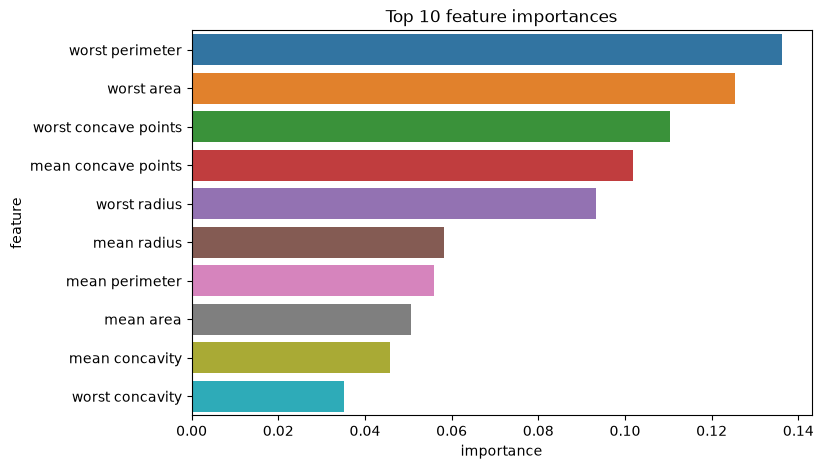

In [13]:
feature_importance_df = pd.DataFrame({
    'feature': cancer.feature_names,
    'importance': rf_clf.feature_importances_
}).sort_values('importance', ascending=False)

# 중요도가 높은 상위 10개 feature만 표로 확인함.
display(feature_importance_df.head(10))

plt.figure(figsize=(8, 5))
sns.barplot(
    data=feature_importance_df.head(10),
    x='importance',
    y='feature',
    hue='feature',
    legend=False
)
plt.title('Top 10 feature importances')
plt.xlabel('importance')
plt.ylabel('feature')
plt.show()

# 중요도 상위 feature의 의미
# == 분기를 구분할 때 조건으로 상대적으로 자주 사용되었다
# (주의)  중요도가 높다고 해서 양성/악성을 분류하는 주된 원인으로 해석하면 안됨

## 10. OOB, test score, 교차검증 비교

- `test score`: 처음 분리해 둔 평가셋으로 계산한 점수임.
- `OOB score`: 각 트리의 bootstrap sample에 뽑히지 않은 데이터로 추정한 점수임.
- `cross_validate()`: 학습 데이터를 여러 fold로 나누어 평균 검증 점수를 계산함.
    - ex) cv = 3 # 학습 데이터를 3개의 폴드로 나누어 검증
    ```
    1회차: fold 1 검증, fold 2 + fold 3 학습
    2회차: fold 2 검증, fold 1 + fold 3 학습
    3회차: fold 3 검증, fold 1 + fold 2 학습
    ```

- 세 점수가 비슷하면 모델 성능 추정이 비교적 안정적이라고 볼 수 있음.


In [14]:
cv_rf_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    max_features='sqrt',
    random_state=42,
    n_jobs=1
)

cv_results = cross_validate(
    cv_rf_clf,
    rf_X_train,
    rf_y_train,
    cv=3,                     # 학습 데이터를 3개 fold로 나누어 3번 검증
    return_train_score=True,  # train_score도 함께 반환해 과대적합 여부를 참고할 수 있음
    scoring='accuracy'        # 분류 정확도를 기준으로 평가
)

# holdout(test 데이터), OOB, cross validation 결과를 한 표에 모아 비교함.
# 서로 다른 평가 방식이 비슷한 값을 보이면 성능 추정이 비교적 안정적이라고 볼 수 있음.
score_summary = pd.DataFrame([
    {
        'metric': 'holdout_test_accuracy',
        'score': rf_clf.score(rf_X_test, rf_y_test)
    },
    {
        'metric': 'oob_score',
        'score': rf_clf.oob_score_
    },
    {
        'metric': 'cv_mean_accuracy',
        'score': cv_results['test_score'].mean()
    }
])

display(score_summary)
print('fold별 검증 accuracy:', np.round(cv_results['test_score'], 4))

# 세 지표가 모두 높고 비슷하면 모델의 성능을 더 신뢰할 수 있다

,metric,score
0,holdout_test_accuracy,0.956140
1,oob_score,0.958242
2,cv_mean_accuracy,0.956039


fold별 검증 accuracy: [0.9671 0.9474 0.9536]


## 11. RandomForestRegressor 회귀 예측

- RandomForestRegressor는 여러 결정트리의 예측값을 평균내어 숫자를 예측함.
- 분류에서는 투표 또는 확률 평균, 회귀에서는 예측값 평균을 사용함.
- 여기서는 Diabetes 데이터로 회귀 예측 흐름을 확인함.


In [15]:
# as_frame=True를 사용해 feature 이름이 있는 DataFrame 형태로 데이터를 받음.
diabetes = load_diabetes(as_frame=True)

# reg_X: 건강 지표 feature 데이터
# reg_y: 1년 후 당뇨 진행 정도를 나타내는 target 값
reg_X = diabetes.data
reg_y = diabetes.target

reg_X_train, reg_X_test, reg_y_train, reg_y_test = train_test_split(
    reg_X,
    reg_y,
    test_size=0.2,
    random_state=42
)

print('회귀 feature shape:', reg_X.shape)
print('회귀 target shape:', reg_y.shape)
display(reg_X.head())


회귀 feature shape: (442, 10)
회귀 target shape: (442,)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [17]:
# RandomForestRegressor 생성
rf_reg = RandomForestRegressor(
    n_estimators=300,
    max_depth=5,
    random_state=42,
    n_jobs=1
)

# 학습
rf_reg.fit(reg_X_train, reg_y_train)

# 평가(R2, RMSE)
reg_pred = rf_reg.predict(reg_X_test)   # 예측

print('학습셋 R2: ', rf_reg.score(reg_X_train, reg_y_train))
print('평가셋 R2: ', rf_reg.score(reg_X_test, reg_y_test))
print('평가셋 RMSE: ', root_mean_squared_error(reg_y_test, reg_pred))

# (참고) Diabetes 데이터 자체가 예측이 어려운 데이터셋

# 학습셋 R2 >> 평가셋 R2 -> overfitting 의심
# (학습셋이 지나치게 높을 때)

학습셋 R2:  0.7398126170636952
평가셋 R2:  0.4573543689863395
평가셋 RMSE:  53.61920270555988


## 12. 회귀 모델 feature importance

- 회귀 Random Forest에서도 feature importance를 확인할 수 있음.
- 어떤 feature가 예측값을 만드는 데 많이 사용되었는지 참고할 수 있음.
- 분류와 마찬가지로 feature importance는 인과관계를 뜻하지 않음.


,feature,importance
2,bmi,0.413740
8,s5,0.283371
3,bp,0.078683
9,s6,0.051350
5,s2,0.042996
0,age,0.037680
4,s1,0.034900
6,s3,0.032428
7,s4,0.019935
1,sex,0.004918


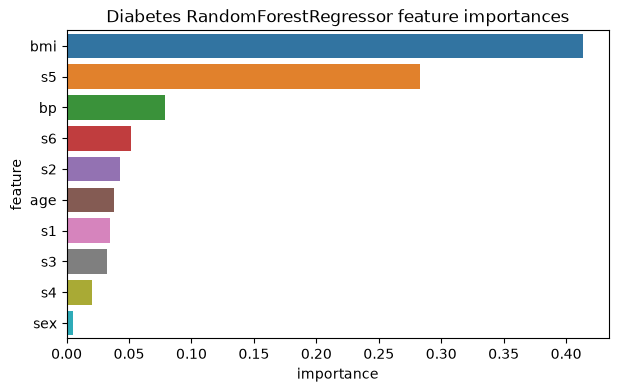

In [18]:
# 값이 큰 feature일수록 예측값을 나누는 트리 분할에 많이 기여한 변수임.
reg_feature_importance_df = pd.DataFrame({
    'feature': diabetes.feature_names,
    'importance': rf_reg.feature_importances_
}).sort_values('importance', ascending=False)

display(reg_feature_importance_df)

plt.figure(figsize=(7, 4))
sns.barplot(
    data=reg_feature_importance_df,
    x='importance',
    y='feature',
    hue='feature',
    legend=False
)
plt.title('Diabetes RandomForestRegressor feature importances')
plt.xlabel('importance')
plt.ylabel('feature')
plt.show()

## 13. RandomForestRegressor 하이퍼파라미터 튜닝

- Random Forest의 성능은 `n_estimators`, `max_depth`, `min_samples_leaf` 같은 설정에 영향을 받음.
- `GridSearchCV`로 후보 조합을 비교하되, 수업에서는 실행 시간을 고려해 후보를 작게 잡음.
- 튜닝은 항상 평가셋 성능 향상을 보장하지 않음. 후보 범위 안에서 교차검증 기준으로 더 나은 설정을 찾는 과정임.


In [19]:
# 하이퍼 파라미터 후보
param_grid = {
    'n_estimators': [100, 300],
    'max_depth': [3, 5, None],
    'min_samples_leaf': [1, 5]
}

grid_rf_reg = RandomForestRegressor(random_state=42, n_jobs=1)

grid_search = GridSearchCV(
    estimator = grid_rf_reg,
    param_grid = param_grid,
    cv = 3,
    scoring='neg_root_mean_squared_error',
    n_jobs=1
)

# 학습
grid_search.fit(reg_X_train, reg_y_train)

# best_estimator_: 교차검증 기준으로 가장 좋았던 하이퍼파라미터가 적용된 모델
best_rf_reg = grid_search.best_estimator_
best_reg_pred = best_rf_reg.predict(reg_X_test)

print('best_params:', grid_search.best_params_)
print('best_cv_RMSE:', -grid_search.best_score_)
print('평가셋 R2:', r2_score(reg_y_test, best_reg_pred))
print('평가셋 RMSE:', root_mean_squared_error(reg_y_test, best_reg_pred))

best_params: {'max_depth': 5, 'min_samples_leaf': 1, 'n_estimators': 300}
best_cv_RMSE: 58.62259582230916
평가셋 R2: 0.4573543689863395
평가셋 RMSE: 53.61920270555988


## 14. Bagging과 Random Forest 정리

- Bagging은 bootstrap sample로 여러 모델을 학습시키고 예측을 결합하는 방식임.
- Random Forest는 Bagging에 feature 랜덤 선택을 더한 결정트리 앙상블임.
- 분류는 여러 트리의 투표 또는 확률 평균으로 예측함.
- 회귀는 여러 트리의 예측값 평균으로 예측함.
- OOB score는 bootstrap에서 뽑히지 않은 데이터를 활용한 자체 검증 점수임.
- feature importance는 모델 해석에 유용하지만 인과관계로 해석하면 안 됨.
